In [ ]:
import pandas as pd
import datetime as dt
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt



In [170]:
ticker = 'NTPC.NS'
price_type = 'Close'
period = 60
df = yf.Ticker(ticker).history(period=f"{period}d", interval="15m").reset_index()

In [171]:
class Report:
    def __init__(self, df,price_type,SMA_period = None, EMA_period = None, volatility_period = None, rsi_period = None):
        self.df = df.copy()
        self.price_type = price_type
        self.SMA_period = SMA_period
        self.EMA_period = EMA_period
        self.volatility_period = volatility_period
        self.rsi_period = rsi_period
        
    def technical_indicators(self):
        # Simple Moving Average
        if self.SMA_period:
            self.df[f'{self.price_type}_SMA_{self.SMA_period}'] = (
                self.df[self.price_type].rolling(self.SMA_period).mean()
            )

        # Exponential Moving Average
        if self.EMA_period:
            self.df[f'{self.price_type}_EMA_{self.EMA_period}'] = (
                self.df[self.price_type].ewm(span=self.EMA_period, adjust=False).mean()
            )

        # Returns
        self.df['Returns'] = self.df[self.price_type].pct_change()

        # Volatility
        if self.volatility_period:
            self.df[f'Volatility_{self.volatility_period}'] = (
                self.df['Returns'].rolling(self.volatility_period).std()
            )
        self.df['Day'] = self.df['Datetime'].dt.day_name()
        self.df.groupby('Day')['Returns'].mean()    
    #Bollinger Bands and RSI
        delta = self.df[self.price_type].diff()
        gain = (delta.where(delta > 0, 0)).rolling(self.rsi_period).mean()
        loss = (-delta.where(delta<0, 0)).rolling(self.rsi_period).mean()
        rs = gain / loss
        self.df['RSI'] = 100 - (100/(1 + rs))

        self.df['Upper_Band'] = self.df[f'{self.price_type}_SMA_{self.SMA_period}'] + 2 * self.df[self.price_type].rolling(self.SMA_period).std()
        self.df['Lower_Band'] = self.df[f'{self.price_type}_SMA_{self.SMA_period}'] - 2 * self.df[self.price_type].rolling(self.SMA_period).std()

        return self.df




In [174]:
report = Report(df, price_type, 10, 20, 20, 14)

result = report.technical_indicators()

result[f'{price_type}_SMA_10']


0              NaN
1              NaN
2              NaN
3              NaN
4              NaN
           ...    
1432    336.754996
1433    336.719995
1434    336.669995
1435    336.729996
1436    336.824994
Name: Close_SMA_10, Length: 1437, dtype: float64

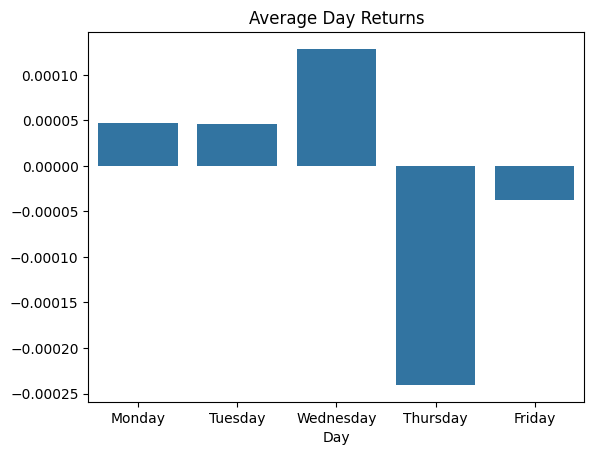

In [164]:
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
monthly_return = result.groupby('Day')['Returns'].mean()
sns.barplot(x = monthly_return.index, y=monthly_return.values, order = order)
plt.title("Average Day Returns")
plt.show()

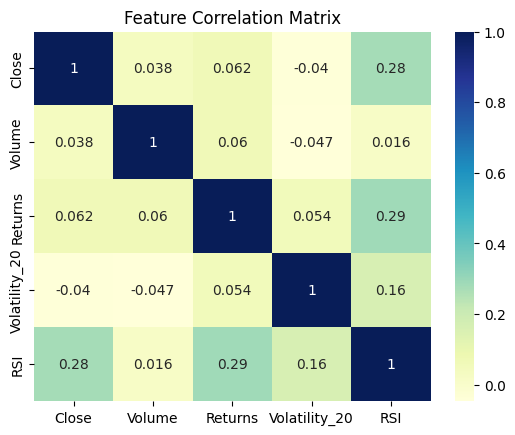

In [165]:
feature_df = result[['Close','Volume','Returns','Volatility_20','RSI']]
sns.heatmap(feature_df.corr(), annot=True, cmap='YlGnBu')
plt.title("Feature Correlation Matrix")
plt.show()

In [166]:
import plotly.graph_objects as go

fig = go.Figure()
# result = result.sort_values('Datetime')
# result = result.interpolate()

# Add Close Price line
fig.add_trace(go.Scatter(
    x=result['Datetime'], 
    y=result['Close'], 
    mode='lines',
    name='Close Price',
    line=dict(color='blue')
))

# Add Upper Band
fig.add_trace(go.Scatter(
    x=result['Datetime'], 
    y=result['Upper_Band'], 
    mode='lines',
    name='Upper Band',
    line=dict(color='red')
))

# Add Lower Band
fig.add_trace(go.Scatter(
    x=result['Datetime'], 
    y=result['Lower_Band'], 
    mode='lines',
    name='Lower Band',
    line=dict(color='black')
))

# Optional: Fill between upper and lower band
fig.add_trace(go.Scatter(
    x=pd.concat([result['Datetime'], result['Datetime'][::-1]]),
    y=pd.concat([result['Upper_Band'], result['Lower_Band'][::-1]]),
    fill='toself',
    fillcolor='rgba(255,0,0,0.1)',
    line=dict(color='rgba(255,255,255,0)'),
    hoverinfo='skip',
    showlegend=False
))

# Layout styling
fig.update_layout(
    title='Bollinger Bands (Interactive)',
    xaxis_title='Date',
    yaxis_title='Price',
    template='plotly_white',
    hovermode='x unified',
    width=1000,
    height=600
)

fig.show()


In [167]:

# def EDA(df, price_type, SMA_period = None, EMA_period = None, volatility_period = None):
#     df[f'{price_type}_SMA_{SMA_period}'] = df[price_type].rolling(SMA_period).mean()
#     df[f'{price_type}_EMA_{EMA_period}'] = df[price_type].ewm(span = EMA_period, adjust = False).mean()
#     df['Returns'] = df[price_type].pct_change()
#     df[f'Volatility_{volatility_period}'] = df['Returns'].rolling(volatility_period).std()
#     return df
